In [4]:
%matplotlib inline

# 	降维与度量学习实验

## 实验目的
掌握k近邻分类器和主成分分析的原理和算法。

## 实验要求
1. 编程实现k邻近分类器，画图给出其分类边界。
1. 编程实现pca函数，对Iris数据集进行降维，观察并解释实验结果。

## 实验内容1
阅读并理解以下代码，**填补对应内容的注释**，总结实验结果和心得体会。

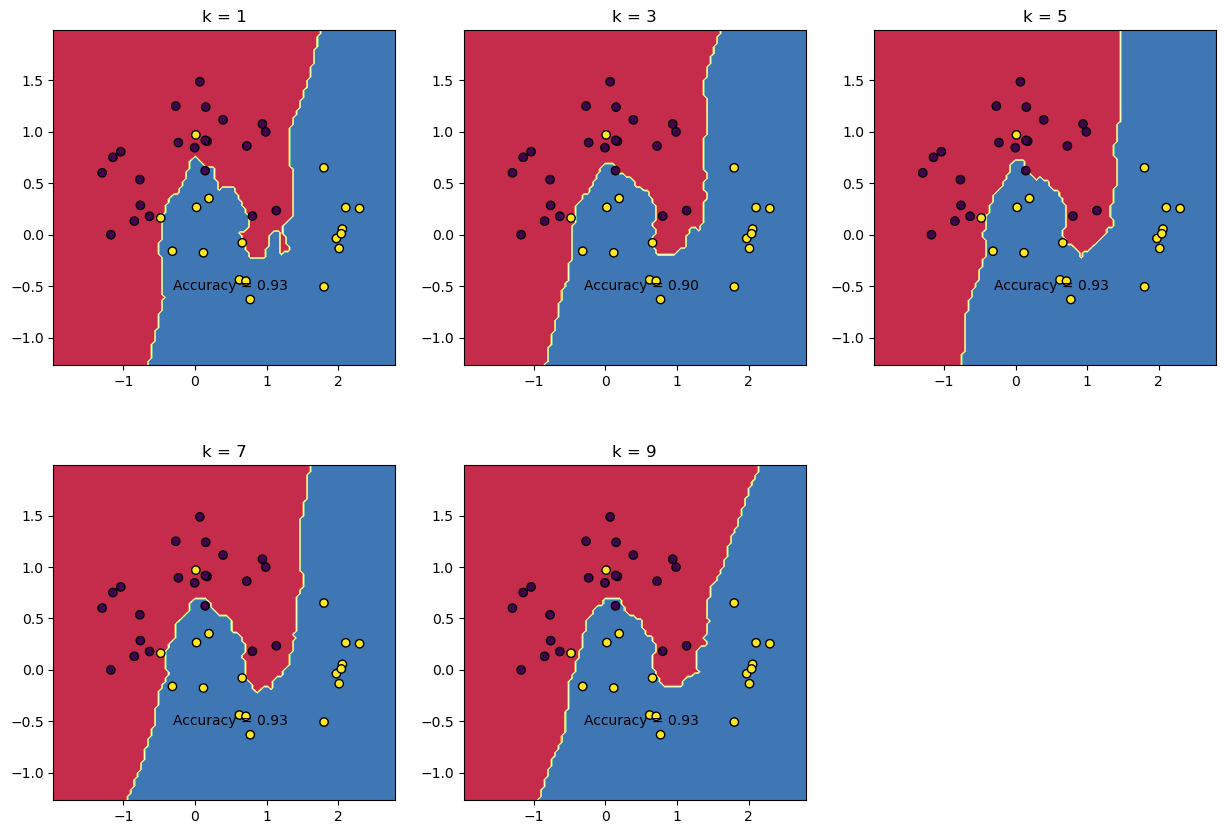

In [5]:
%reset -f
# 导入必要的模块
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 定义k近邻分类器函数
def knn(X, y, Z, k):
  # 初始化预测标签向量，长度等于待预测样本数
  pred = np.zeros(Z.shape[0])
  # 遍历每个待预测样本，逐一进行分类
  for i in range(Z.shape[0]):
    # 计算当前待预测样本到所有训练样本的欧氏距离
    dist = np.sqrt(np.sum((X - Z[i])**2, axis=1))
    # 对距离排序，取前k个最近邻样本的索引
    idx = np.argsort(dist)[:k]
    # 统计k个近邻中每个类别出现的次数
    count = np.bincount(y[idx])
    # 选择出现次数最多的类别作为当前样本的预测标签（多数投票）
    pred[i] = np.argmax(count)
  # 返回预测标签向量
  return pred

# 生成二分类数据集（半月形数据，含噪声）
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
# 划分训练集和测试集，按8:2比例
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 定义不同的k值列表，用于比较不同k对分类结果的影响
k_list = [1, 3, 5, 7, 9]
# 定义画布大小和子图布局
plt.figure(figsize=(15, 10))
plt.subplots_adjust(hspace=0.3)
# 遍历不同的k值，画出每个k对应的分类边界和测试集散点图
for i in range(len(k_list)):
  # 调用k近邻分类器函数，对测试集进行分类，并计算分类准确率
  k = k_list[i]
  pred = knn(X_train, y_train, X_test, k)
  acc = np.mean(pred == y_test)
  # 定义网格点，用于画出分类边界（在整个数据范围内创建均匀网格）
  x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
  y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
  # 对网格上的每个点进行分类，得到分类边界
  zz = knn(X_train, y_train, np.c_[xx.ravel(), yy.ravel()], k).reshape(xx.shape)
  # 在子图中画出分类边界（背景色）和测试样本的散点图，并显示k值和准确率
  plt.subplot(2, 3, i+1)
  plt.contourf(xx, yy, zz, cmap=plt.cm.Spectral)
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k')
  plt.title(f"k = {k}")
  plt.text(0.5, -0.5, f"Accuracy = {acc:.2f}", horizontalalignment='center', verticalalignment='center')
# 显示所有子图
plt.show()

## 上机内容2

阅读并理解以下代码，总结实验结果和心得体会。

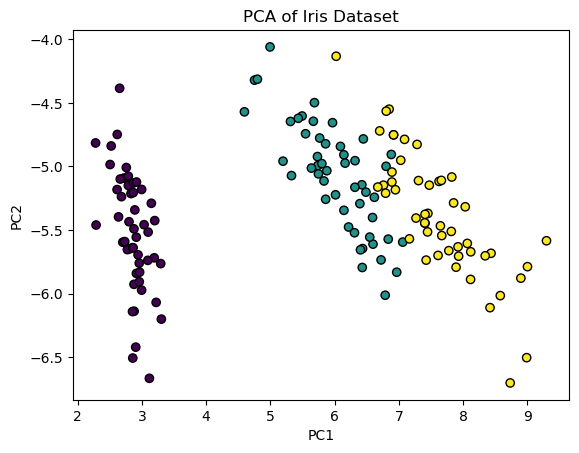

各主成分的方差贡献率: [0.92461872 0.05306648 0.01710261 0.00521218]
前2个主成分的累计方差贡献率: 97.77%


In [6]:
%reset -f
# 导入必要的模块
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 定义主成分分析函数
def pca(X, d):
    # 计算数据矩阵的均值向量和协方差矩阵（中心化后求协方差）
    mean = np.mean(X, axis=0)
    cov = np.cov(X.T)
    # 计算协方差矩阵的特征值和特征向量，并按特征值降序排列
    eig_val, eig_vec = np.linalg.eig(cov)
    idx = np.argsort(eig_val)[::-1]
    eig_val = eig_val[idx]
    eig_vec = eig_vec[:, idx]
    # 取前d个最大的特征值对应的特征向量作为投影矩阵（主成分）
    W = eig_vec[:, :d]
    # 将原始数据矩阵投影到低维空间，得到降维后的数据矩阵
    Z = X.dot(W)
    # 返回降维后的数据矩阵和特征向量矩阵
    return Z, W

# 加载鸢尾花数据集（150个样本，4个特征，3个类别）
X, y = load_iris(return_X_y=True)
# 调用主成分分析函数，取d=2将4维数据降到2维
d = 2
Z, W = pca(X, d)
# 画出降维后的数据点和原始标签的散点图，观察降维后的数据分布
plt.scatter(Z[:, 0], Z[:, 1], c=y, edgecolors='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Iris Dataset')
plt.show()

# 计算并输出各主成分的方差贡献率（解释方差比）
cov = np.cov(X.T)
eig_val, eig_vec = np.linalg.eig(cov)
eig_val = np.sort(eig_val)[::-1]
explained_var_ratio = eig_val / np.sum(eig_val)
print(f"各主成分的方差贡献率: {explained_var_ratio}")
print(f"前2个主成分的累计方差贡献率: {np.sum(explained_var_ratio[:2]):.2%}")